In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

In [ ]:
dataset = pd.read_csv('student_performance_dirty.csv')

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,Notes
0,7.0,99,Yes,9.0,1,91.0,excellent
1,4.0,82,No,4.0,2,65.0,review
2,8.0,51,Yes,7.0,2,45.0,review
3,5.0,52,Yes,5.0,2,36.0,excellent
4,7.0,75,No,8.0,5,66.0,review


In [ ]:
dataset.head()

In [ ]:
dataset.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,8973.000000,10005.000000,9509.000000,10005.000000,10005.000000
mean,4.997325,69.437581,6.529078,4.590205,55.215792
std,2.590449,17.343872,1.696752,2.892721,19.213705
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,27.000000,100.000000


In [ ]:
dataset.isnull().sum()

,0
Hours Studied,1032
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,496
Sample Question Papers Practiced,0
Performance Index,0
Notes,0


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10005 entries, 0 to 10004
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     8973 non-null   float64
 1   Previous Scores                   10005 non-null  int64  
 2   Extracurricular Activities        10005 non-null  object 
 3   Sleep Hours                       9509 non-null   float64
 4   Sample Question Papers Practiced  10005 non-null  int64  
 5   Performance Index                 10005 non-null  float64
 6   Notes                             10005 non-null  object 
dtypes: float64(3), int64(2), object(2)
memory usage: 547.3+ KB


In [ ]:
print("Duplicates before:", dataset.duplicated().sum())

Duplicates before: 44


In [ ]:
#handling duplicates
dataset = dataset.drop_duplicates()

print("Duplicates after:", dataset.duplicated().sum())
print("Dataset shape after removing duplicates:", dataset.shape)

Duplicates after: 0
Dataset shape after removing duplicates: (9961, 7)


In [ ]:
#handling missing values
print(dataset.isnull().sum())
dataset = dataset.fillna(dataset.mean(numeric_only=True))

Hours Studied                       1030
Previous Scores                        0
Extracurricular Activities             0
Sleep Hours                          496
Sample Question Papers Practiced       0
Performance Index                      0
Notes                                  0
dtype: int64


In [ ]:
#HANDLING OUTLIERS
def remove_outliers_iqr(dataset):
    numeric_cols = dataset.select_dtypes(include=['number']).columns
    cleaned_dataset = dataset.copy()

    for col in numeric_cols:
        Q1 = cleaned_dataset[col].quantile(0.25)
        Q3 = cleaned_dataset[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        cleaned_dataset = cleaned_dataset[
            (cleaned_dataset[col] >= lower_bound) &
            (cleaned_dataset[col] <= upper_bound)
        ]

    return cleaned_dataset

In [ ]:
outliers_id = remove_outliers_iqr(dataset)
print(outliers_id)

       Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0                7.0               99                        Yes      9.00000   
1                4.0               82                         No      4.00000   
2                8.0               51                        Yes      7.00000   
3                5.0               52                        Yes      5.00000   
4                7.0               75                         No      8.00000   
...              ...              ...                        ...          ...   
9996             7.0               64                        Yes      6.52879   
9997             6.0               83                        Yes      8.00000   
9998             9.0               97                        Yes      7.00000   
9999             7.0               74                         No      8.00000   
10004            7.0               53                         No      4.00000   

       Sample Question Pape

In [ ]:
# result of handling outliers
print("Shape before removing outliers", dataset.shape)
dataset = remove_outliers_iqr(dataset)
print("Shape after removing outliers", dataset.shape)

Shape before removing outliers (9961, 7)
Shape after removing outliers (9958, 7)


In [ ]:
print(dataset.columns)

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index',
       'Notes'],
      dtype='object')


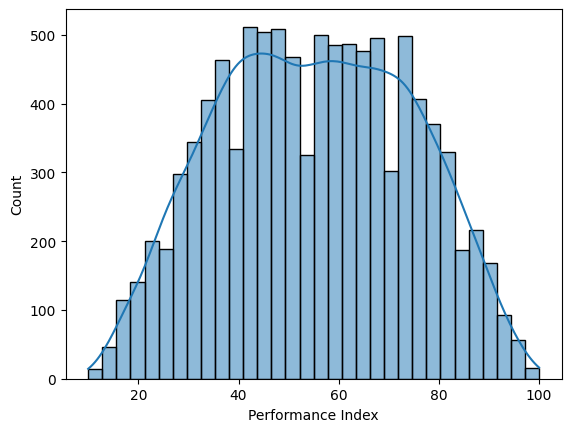

In [ ]:
sns.histplot(dataset['Performance Index'], kde=True)
plt.show()

In [ ]:
# 1. Feature / target split
target_col = "Performance Index"

# Drop target and optional text column "Notes" if it exists
cols_to_drop = [c for c in ["Performance Index", "Notes"] if c in dataset.columns]

In [ ]:
X = dataset.drop(columns=cols_to_drop)
y = dataset[target_col]

# 2. Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# Split coulmns as numaric and categorical
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

In [ ]:
# Encoding the dataset
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [ ]:
# 4. Pipelines for each model
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

svr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVR(kernel="rbf", C=100, gamma="scale"))
])

In [ ]:
lr_pipeline.fit(X_train, y_train)
svr_pipeline.fit(X_train, y_train)

# 6. Predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_svr = svr_pipeline.predict(X_test)

In [ ]:
def regression_report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(name)
    print("-" * 40)
    print(f"MAE : {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²  : {r2:.3f}\n")

    return mae, rmse, r2

In [ ]:
print("=== Model performance on test set ===\n")
lr_mae, lr_rmse, lr_r2 = regression_report("Linear Regression", y_test, y_pred_lr)
svr_mae, svr_rmse, svr_r2 = regression_report("SVR (RBF kernel)", y_test, y_pred_svr)

=== Model performance on test set ===

Linear Regression
----------------------------------------
MAE : 2.100
RMSE: 3.006
R²  : 0.975

SVR (RBF kernel)
----------------------------------------
MAE : 2.140
RMSE: 3.042
R²  : 0.974



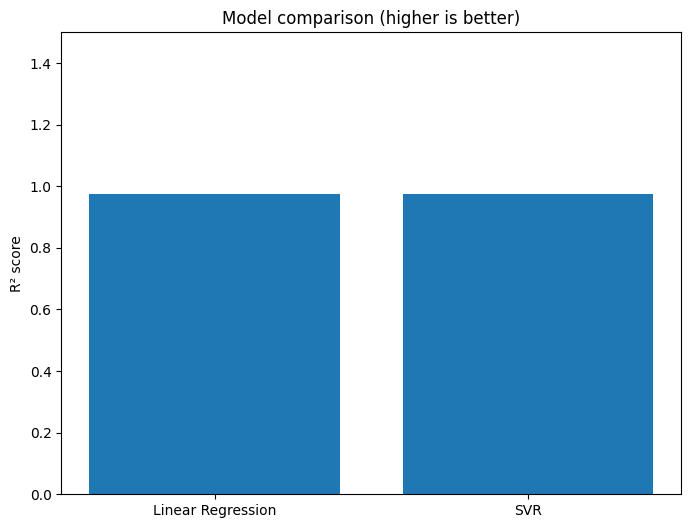

In [ ]:
models = ["Linear Regression", "SVR"]
r2_scores = [lr_r2, svr_r2]

plt.figure(figsize=(8, 6))
plt.bar(models, r2_scores)
plt.ylabel("R² score")
plt.title("Model comparison (higher is better)")
plt.ylim(0, 1.5)
plt.show()

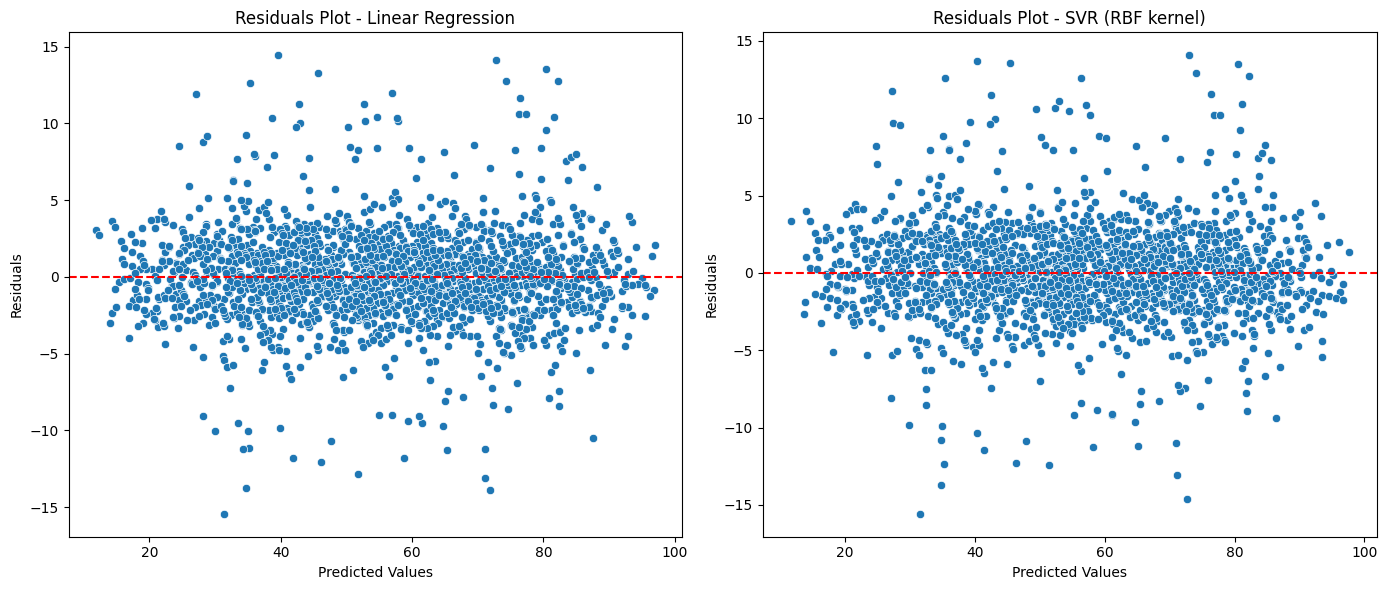

In [ ]:
# Compute residuals
lr_residuals = y_test - y_pred_lr
svr_residuals = y_test - y_pred_svr

plt.figure(figsize=(14, 6))

# --- Linear Regression Residual Plot ---
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_lr, y=lr_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals Plot - Linear Regression")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# --- SVR Residual Plot ---
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_svr, y=svr_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals Plot - SVR (RBF kernel)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()


In [ ]:
print("=== Cross-Validation Results (5-Fold) ===\n")
# R² scores for LR
lr_cv = cross_val_score(lr_pipeline, X, y, cv=5, scoring='r2')
print(f"Linear Regression R² scores: {lr_cv}")
print(f"Mean R²: {lr_cv.mean():.4f}\n")

# R² scores for SVR
svr_cv = cross_val_score(svr_pipeline, X, y, cv=5, scoring='r2')
print(f"SVR R² scores: {svr_cv}")
print(f"Mean R²: {svr_cv.mean():.4f}")


=== Cross-Validation Results (5-Fold) ===

Linear Regression R² scores: [0.9740291  0.97120011 0.9752356  0.97448939 0.97434034]
Mean R²: 0.9739

SVR R² scores: [0.9732911  0.97041952 0.97425298 0.97368691 0.97363544]
Mean R²: 0.9731
